<a href="https://colab.research.google.com/github/saif-011/Python-Lab-MCAIII/blob/main/DS_Ques.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import numpy as np
import pandas as pd

x1=np.random.uniform(1,18,1000)  #study
x2=np.random.uniform(6,23,1000)  #sleep
y=['Pass','Fail']
data={
    'x1': x1,
    'x2': x2,
    'y': np.random.choice(y,1000)
}

df=pd.DataFrame(data)
df.head()

,x1,x2,y
0,7.089126,20.867412,Pass
1,12.619058,15.388790,Fail
2,5.571128,7.014463,Fail
3,3.488068,10.673919,Pass
4,10.442131,19.777552,Pass


Seprating Independent and dependent variable

In [10]:
#df=df.dropna(axis=0,inplace=True)
X=df.drop(['y'], axis=1)
Y=df['y']
df.head()


,x1,x2,y
0,7.089126,20.867412,Pass
1,12.619058,15.388790,Fail
2,5.571128,7.014463,Fail
3,3.488068,10.673919,Pass
4,10.442131,19.777552,Pass


Splitt Train and Test

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test =train_test_split(X,Y,test_size=0.2,random_state=2)


Scalling

In [12]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)



Corealtion Matix

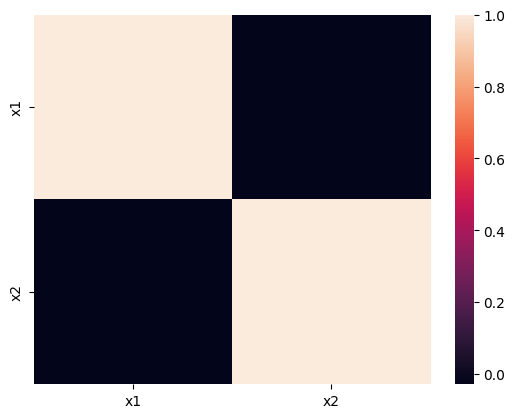

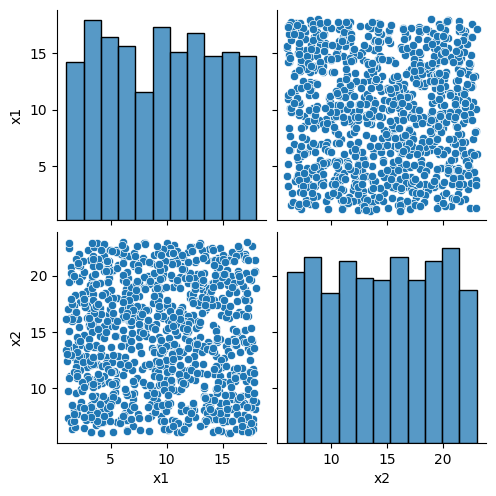

In [14]:
import seaborn as sns

co=X.corr()
sns.heatmap(co)
sns.pairplot(X)

Model training

In [21]:
from sklearn.ensemble import VotingClassifier , RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

basemodel=[('RF' , RandomForestClassifier(n_estimators=100, random_state=2)),
            ('DT', DecisionTreeClassifier()),
              ('KNN', KNeighborsClassifier(n_neighbors=100)),
               ('MLP', MLPClassifier(hidden_layer_sizes=(100,50),max_iter=100,random_state=2)),
               ('SVC', SVC(probability=True))]
voting_classifier=VotingClassifier(estimators=basemodel, voting='hard')
voting_classifier.fit(X_train,Y_train)
Y_pred=voting_classifier.predict(X_test)
accuracy=accuracy_score(Y_test,Y_pred)
print(accuracy)


/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


0.435


Bagging

In [32]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import BaggingRegressor

LE=LabelEncoder()
Y_test_Encoded=LE.fit_transform(Y_test)
Y_train_Encoded=LE.transform(Y_train)
#print(Y_test_Encoded)

BaggModel = BaggingRegressor(estimator= LinearRegression() , n_estimators=100, bootstrap=True)
BaggModel.fit(X_train,Y_train_Encoded)
Y_pred_reg=BaggModel.predict(X_test)
Y_pred_class=np.where(Y_pred_reg >=0.5, 1, 0)
accuracyBagg=accuracy_score(Y_test_Encoded ,Y_pred_class)
print(accuracyBagg)



0.445


Ques3:- Implement Adaboost and Gradient Boosting from scratch having 5 predictors: Linear Regression, Decision Tree, Logistic Regression, Random Forrest, and K Nearest Neighbour.


In [34]:
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression

Adamodel=AdaBoostClassifier(estimator=LogisticRegression() ,n_estimators = 100 , random_state=2)
Adamodel.fit(X_train,Y_train)
Y_pred_Ada=Adamodel.predict(X_test)
accuracyAda= accuracy_score(Y_test , Y_pred_Ada)
print(accuracyAda)

Gradb_model=GradientBoostingClassifier(n_estimators= 100, learning_rate=0.3,max_depth=5 ,random_state=2)
Gradb_model.fit(X_train,Y_train)
Y_pred_Gradb=Gradb_model.predict(X_test)
accuracyGradb= accuracy_score(Y_test , Y_pred_Gradb)
print(accuracyGradb)

/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


0.435
0.54


Ques 4:- Create and implement Stacking ensemble ML Model utilizing 3 predictors at layer 1 and 3 predictors at layer 2.  


In [41]:
from sklearn.ensemble import StackingClassifier
from sklearn.naive_bayes import GaussianNB

base_layer1=[('rfc', RandomForestClassifier(n_estimators=100, random_state=2)),('dtc',DecisionTreeClassifier()),('knn',KNeighborsClassifier(n_neighbors=10))]

stack_layer1=StackingClassifier(estimators=base_layer1, final_estimator=LogisticRegression())

base_layer2=[('mlp',MLPClassifier(hidden_layer_sizes=100, max_iter=50, random_state=2)),

             ('svc',SVC(probability=True)),
              ('gnb',GaussianNB())]
stack_layer2=StackingClassifier(estimators=base_layer2, final_estimator=LogisticRegression())

stack_final=StackingClassifier(estimators=[('stack_layer1', stack_layer1)], final_estimator=stack_layer2)
stack_final.fit(X_train, Y_train)

y_pred_stack=stack_final.predict(X_test)
accuracy_stack=accuracy_score(Y_test, y_pred_stack)
print(accuracy_stack)


0.475


Ques5:- ou have been given a dataset having n independent features, let say x1, x2, x3......, xn and independent features as y, which is categorical (0/1). Train a Polynomial Regression model for this dataset and find out the most suitable degree such that after this degree there is no such significant change in the accuracy.

In [42]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

degree = 1


lr = LinearRegression()

prev_acc = 0

while(True):
    pf = PolynomialFeatures(degree = degree)
    X_train_poly = pf.fit_transform(X_train)
    X_test_poly = pf.transform(X_test)

    lr.fit(X_train_poly, Y_train_Encoded)

    y_pred_reg = lr.predict(X_test_poly)

    y_pred_class = np.where(y_pred_reg >= 0.5, 1, 0)

    curr_acc = accuracy_score(Y_test_Encoded, y_pred_class)
    print(curr_acc)
    print('d: ', degree)
    if curr_acc - prev_acc <= 0.2:
        print(curr_acc)
        break

    prev_acc = curr_acc


    degree = degree + 1

print(degree)

0.435
d:  1
0.45
d:  2
0.45
2
